In [426]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.activations import linear, relu, sigmoid
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
#plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

#from public_tests import * 

from autils import *
#from lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)

In [427]:
df = pd.read_csv("/Users/maryammaryam/Documents/GitHub/CS_129/nba_data/final/nba_ml_dataset.csv")


In [428]:
target = "reg_season_wins"
ignore_cols = ["season","team","reg_season_wins","reg_losses","team_avg_bpm","team_avg_per","team_max_usg","team_players_qualified","team_total_vorp","team_total_ws","team_usg_gini"]
feature_cols = [c for c in df.columns if c not in ignore_cols]
feature_cols = [
    c for c in feature_cols
    if df[c].dtype != "object"
]

In [429]:
print(feature_cols)

['split', 'p1_height_cm', 'p1_weight_kg', 'p1_age', 'p1_assistPercent', 'p1_assists', 'p1_blockPercent', 'p1_blocks', 'p1_box', 'p1_defensiveBox', 'p1_defensiveRBPercent', 'p1_defensiveRb', 'p1_defensiveWS', 'p1_effectFgPercent', 'p1_fieldAttempts', 'p1_fieldGoals', 'p1_fieldPercent', 'p1_ft', 'p1_ftAttempts', 'p1_ftPercent', 'p1_ftr', 'p1_games', 'p1_gamesStarted', 'p1_minutesPg', 'p1_minutesPlayed', 'p1_offensiveBox', 'p1_offensiveRBPercent', 'p1_offensiveRb', 'p1_offensiveWS', 'p1_per', 'p1_personalFouls', 'p1_points', 'p1_position', 'p1_stealPercent', 'p1_steals', 'p1_threeAttempts', 'p1_threeFg', 'p1_threePAR', 'p1_threePercent', 'p1_totalRBPercent', 'p1_totalRb', 'p1_tsPercent', 'p1_turnoverPercent', 'p1_turnovers', 'p1_twoAttempts', 'p1_twoFg', 'p1_twoPercent', 'p1_usagePercent', 'p1_vorp', 'p1_winShares', 'p1_winSharesPer', 'p2_height_cm', 'p2_weight_kg', 'p2_age', 'p2_assistPercent', 'p2_assists', 'p2_blockPercent', 'p2_blocks', 'p2_box', 'p2_defensiveBox', 'p2_defensiveRBPerc

In [430]:
#Split dataset
train_df = df[(df["season"] >= 2016) & (df["season"] <= 2023)]
val_df = df[(df["season"] == 2024)]
test_df = df[(df["season"] == 2025)]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_val = val_df[feature_cols]
y_val = val_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

In [431]:
#Fill missing values
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

In [432]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [433]:
X_train = np.array(X_train, dtype=np.float32)
X_val = np.array(X_val, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

In [434]:
tf.random.set_seed(1234) # for consistent results
model = Sequential(
    [   
        tf.keras.Input(shape=(X_train.shape[1],)),
        Dense(256, activation='relu', kernel_regularizer=l2(0.002)),
        #Dropout(0.3),
        Dense(128, activation = 'relu', kernel_regularizer=l2(0.002)),
        Dense(64, activation = 'relu', kernel_regularizer=l2(0.002)),
        Dense(1)
        ### END CODE HERE ### 
    ], name = "my_model" 
)

In [435]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = "mse", 
    metrics = ["mae"]
)
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_91 (Dense)                │ (None, 256)            │       128,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,729 (663.00 KB)

 Trainable params: 169,729 (663.00 KB)

 Non-trainable params: 0 (0.00 B)

In [436]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # watch validation loss
    patience=10,              # stop after 10 epochs without improvement
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=1, 
    callbacks=[early_stop]
)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1477.4601 - mae: 36.7548 - val_loss: 1262.4485 - val_mae: 33.6953
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 821.6746 - mae: 26.8962 - val_loss: 417.2578 - val_mae: 18.0997
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 211.9658 - mae: 12.4240 - val_loss: 323.1680 - val_mae: 13.9449
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 165.8610 - mae: 9.5851 - val_loss: 134.6549 - val_mae: 9.5572
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 55.7643 - mae: 5.9324 - val_loss: 120.9126 - val_mae: 8.9284
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 43.2378 - mae: 5.1334 - val_loss: 75.2083 - val_mae: 6.9994
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22.9272 - mae: 3.6518 - val_loss: 72.7256 - val_mae: 6.9011
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14.4971 - mae: 2.8781 - val_loss: 71.4588 - val_mae: 6.3321
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/st

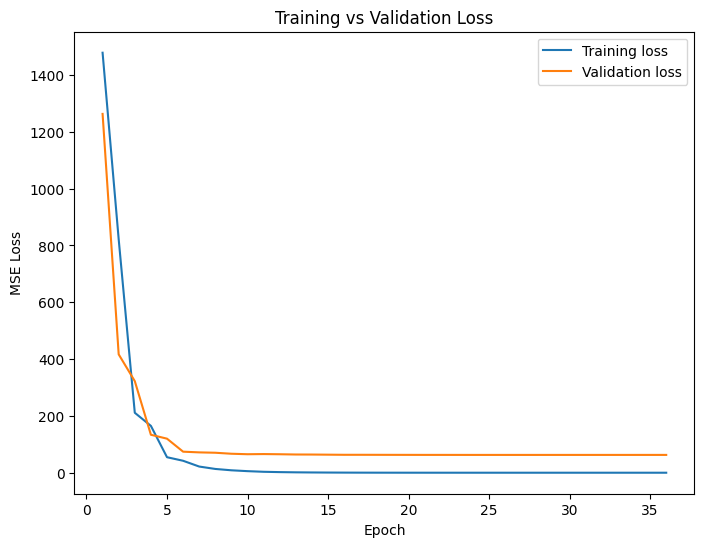

In [437]:
#Plot training vs validation loss
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs_range, train_loss, label="Training loss")
plt.plot(epochs_range, val_loss, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [438]:
# Predictions
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)
test_preds = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [439]:
# Evaluate model
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_r2 = r2_score(y_train, train_preds)
val_r2 = r2_score(y_val, val_preds)
test_r2 = r2_score(y_test, test_preds)

train_mae = mean_absolute_error(y_train, train_preds)
val_mae = mean_absolute_error(y_val, val_preds)
test_mae = mean_absolute_error(y_test, test_preds)

print("\nTrain Results: ")
print("RMSE:", train_rmse)
print("R2 Score:", train_r2)
print("MAE:", train_mae)

print("\nValidation Results: ")
print("RMSE:", val_rmse)
print("R2 Score:", val_r2)
print("MAE:", val_mae)


print("\nTest Results:")
print("RMSE:", test_rmse)
print("R2 Score:", val_r2)
print("MAE:", test_mae)


Train Results: 
RMSE: 0.046913491280545866
R2 Score: 0.9999837875366211
MAE: 0.030190041288733482

Validation Results: 
RMSE: 7.910187596388507
R2 Score: 0.6401203870773315
MAE: 6.070566177368164

Test Results:
RMSE: 10.34171849149946
R2 Score: 0.6401203870773315
MAE: 8.238289833068848


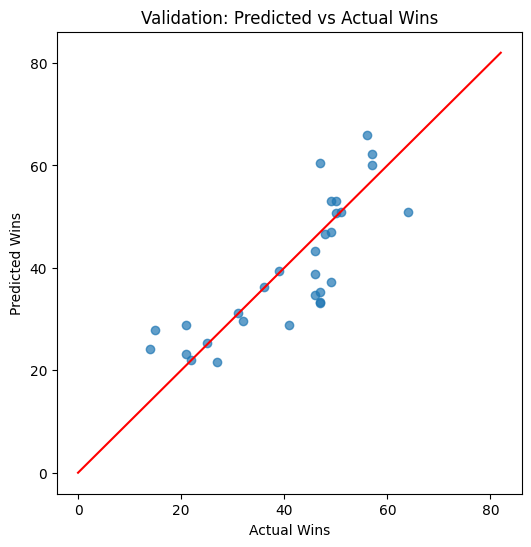

In [440]:
# Validation precdiction graph
plt.figure(figsize=(6,6))

plt.scatter(y_val, val_preds, alpha=0.7)

plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")

plt.title("Validation: Predicted vs Actual Wins")

plt.plot([0,82], [0,82], color="red")

plt.show()

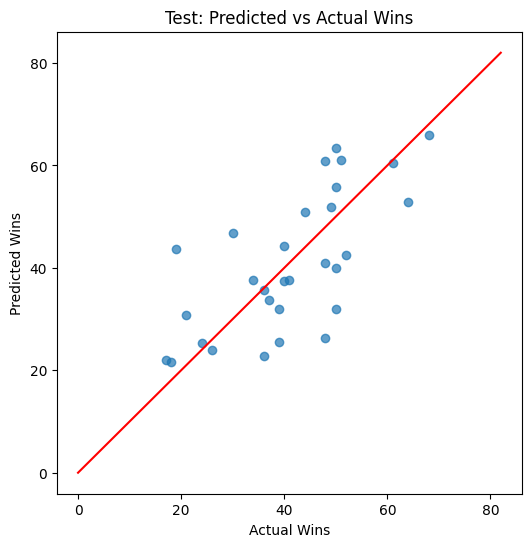

In [441]:
#Test Prediction Graph
plt.figure(figsize=(6,6))

plt.scatter(y_test, test_preds, alpha=0.7)

plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")

plt.title("Test: Predicted vs Actual Wins")

plt.plot([0,82], [0,82], color="red")

plt.show()

In [442]:
predictions = pd.DataFrame({
    "Actual Wins": y_test, 
    "Predicted Wins": test_preds.flatten()
})
print("\nSample Predictions")
print(predictions.head())


Sample Predictions
   Actual Wins  Predicted Wins
0         40.0       44.353649
1         61.0       60.384136
2         26.0       23.996716
3         19.0       43.719772
4         39.0       25.603191


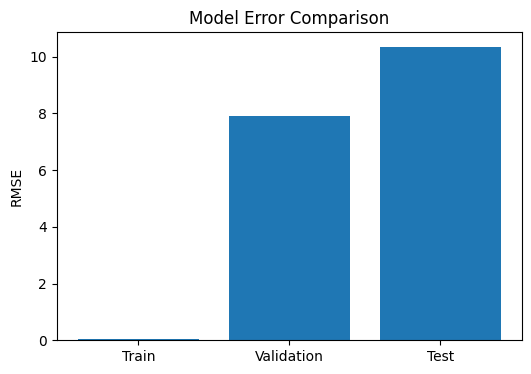

In [443]:
labels = ["Train", "Validation", "Test"]
errors = [train_rmse, val_rmse, test_rmse]

plt.figure(figsize=(6,4))

plt.bar(labels, errors)

plt.ylabel("RMSE")
plt.title("Model Error Comparison")

plt.show()